# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [1]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    # Heuristically decide to extract once
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Extracted: Flower Classification.zip -> data/flower_data
Candidate dataset roots: ['data/flower_data/Data', 'data/flower_data/Data/train', 'data/flower_data/Data/val']


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [2]:
# PREFILLED: just execute
import tensorflow as tf
from keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

Layout: provided_split Base: data/flower_data/Data


In [3]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Classes: 14 ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [4]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

{'astilbe': 726,
 'bellflower': 872,
 'black_eyed_susan': 986,
 'calendula': 1011,
 'california_poppy': 1021,
 'carnation': 924,
 'common_daisy': 978,
 'coreopsis': 1035,
 'dandelion': 1038,
 'iris': 1041,
 'rose': 986,
 'sunflower': 1013,
 'tulip': 1034,
 'water_lily': 977}

In [5]:
# To-Do: implement visualize_images to display a 3x3 grid for each class
import matplotlib.pyplot as plt
import numpy as np

def visualize_images(dataset, class_names, per_class=9):
    # Store collected images for each class
    images_by_class = {i: [] for i in range(len(class_names))}
    
    # Go through batches in the dataset
    for images, labels in dataset:
        images = images.numpy()
        labels = labels.numpy()
        
        for img, label in zip(images, labels):
            if len(images_by_class[label]) < per_class:
                images_by_class[label].append(img.astype("uint8"))
        
        # Stop early if all classes already have enough images
        if all(len(images_by_class[i]) >= per_class for i in range(len(class_names))):
            break

    # Plot one 3x3 grid per class
    for class_idx, class_name in enumerate(class_names):
        fig, axes = plt.subplots(3, 3, figsize=(7, 7))
        fig.suptitle(class_name, fontsize=16)
        axes = axes.flatten()
        
        class_images = images_by_class[class_idx]
        
        for i in range(9):
            ax = axes[i]
            if i < len(class_images):
                ax.imshow(class_images[i])
            ax.axis("off")
        
        plt.tight_layout()
        plt.show()

**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


W0000 00:00:1776011466.951740 13773151 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


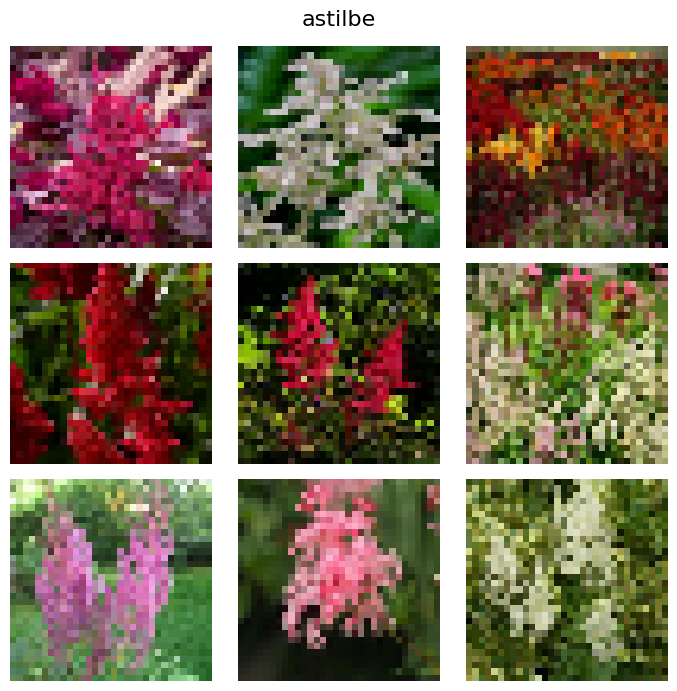

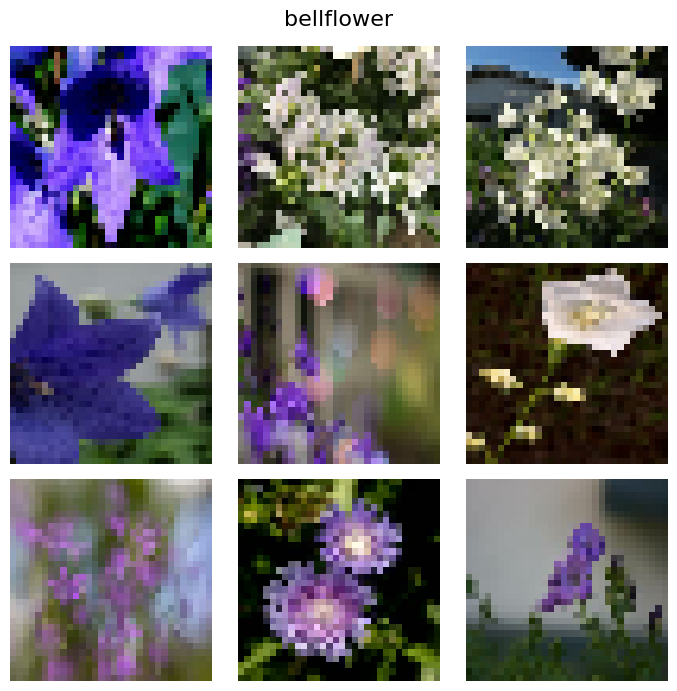

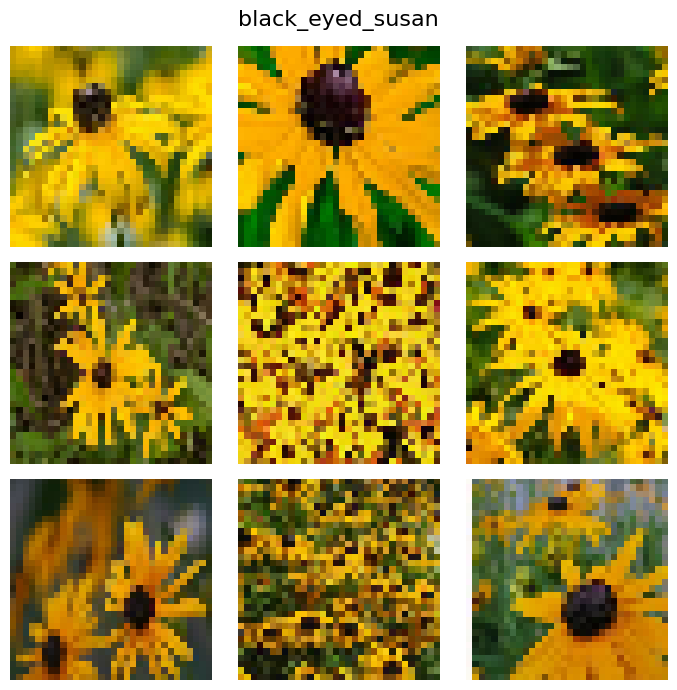

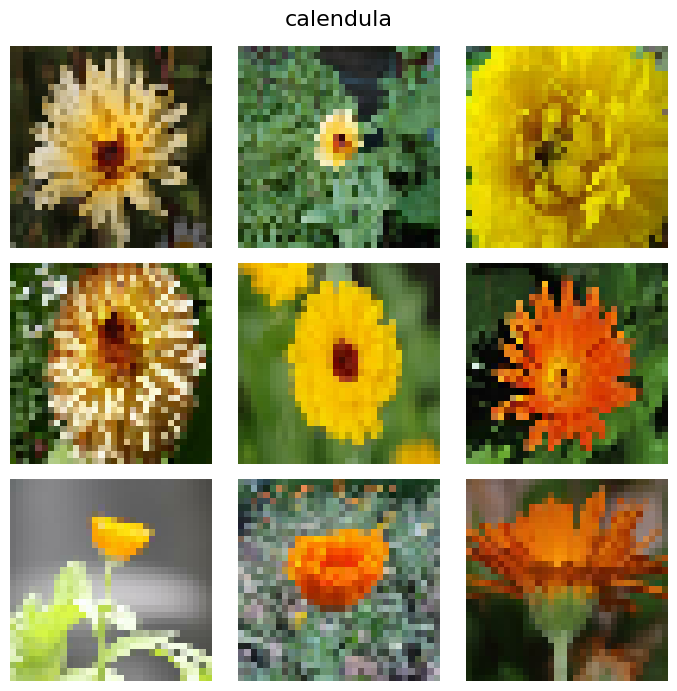

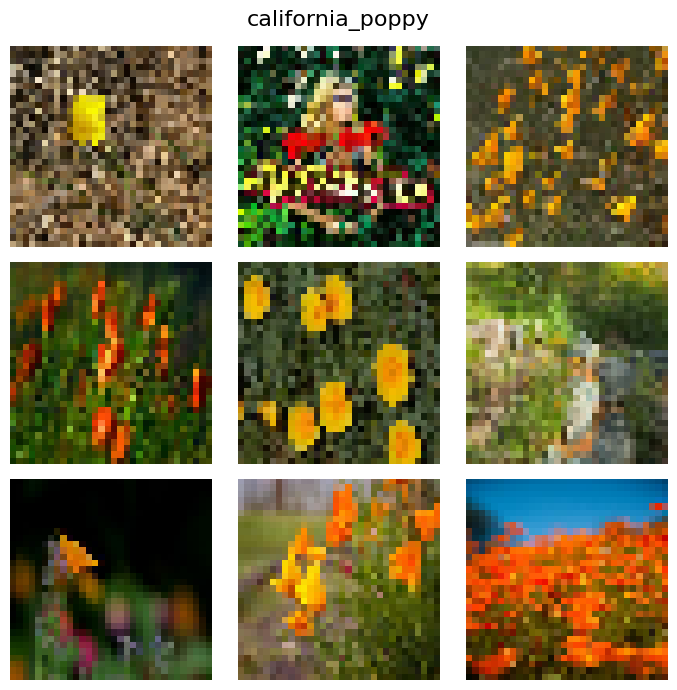

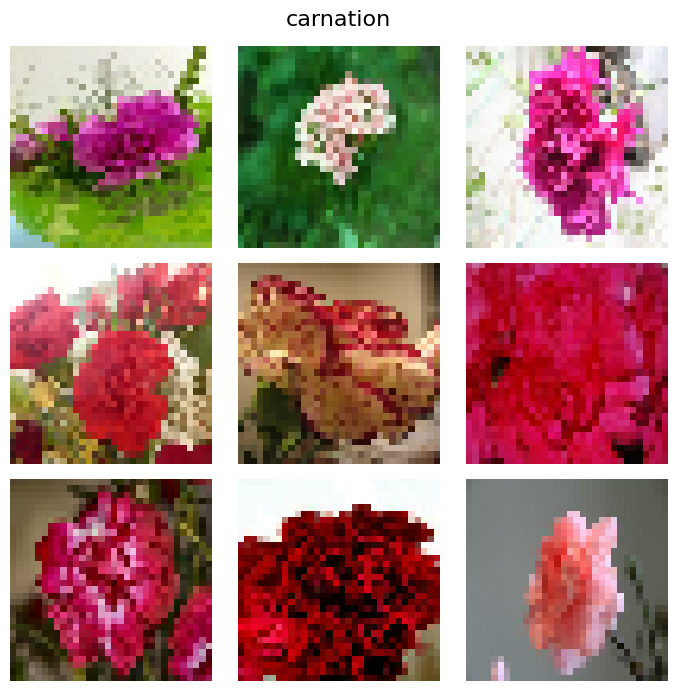

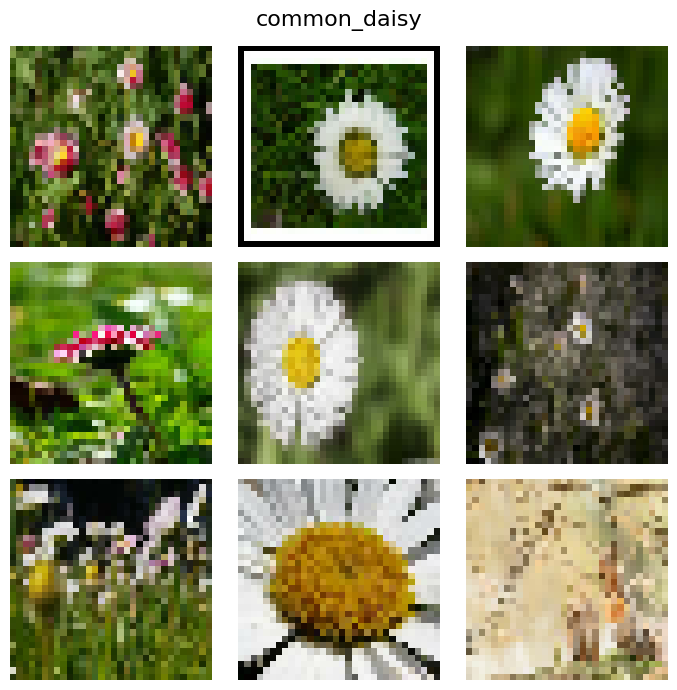

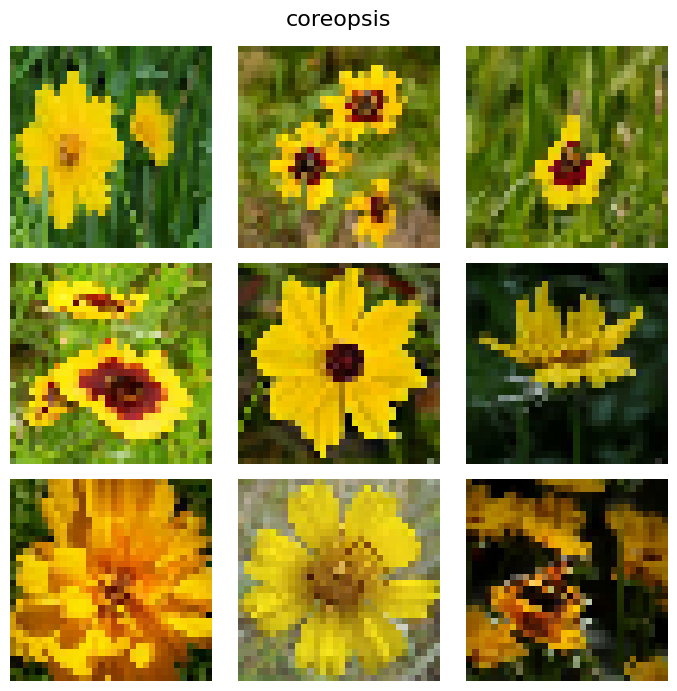

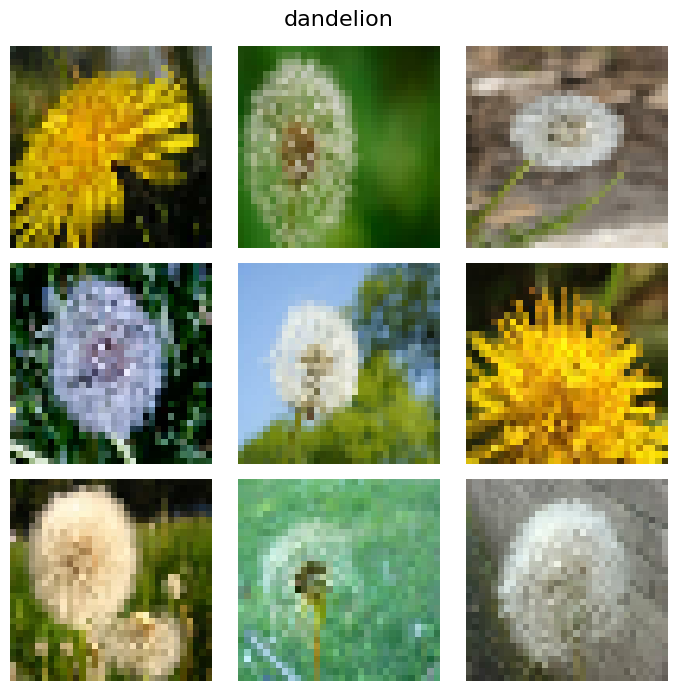

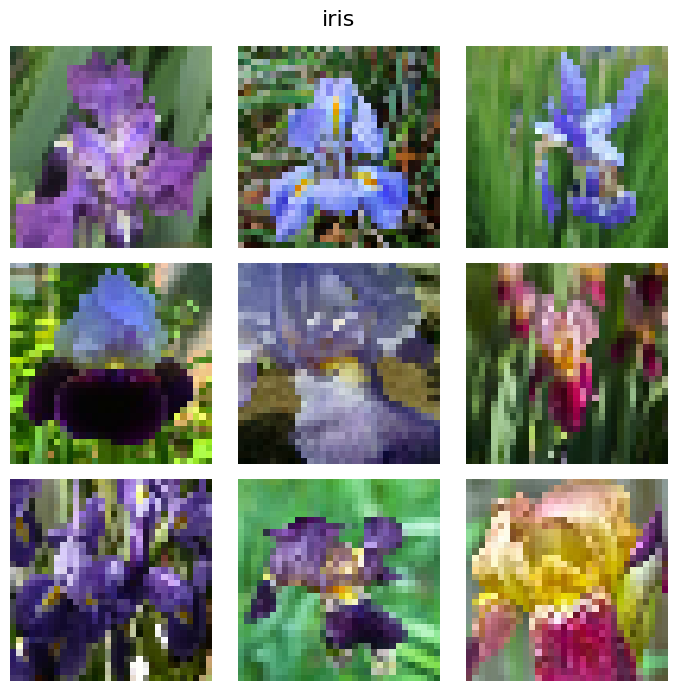

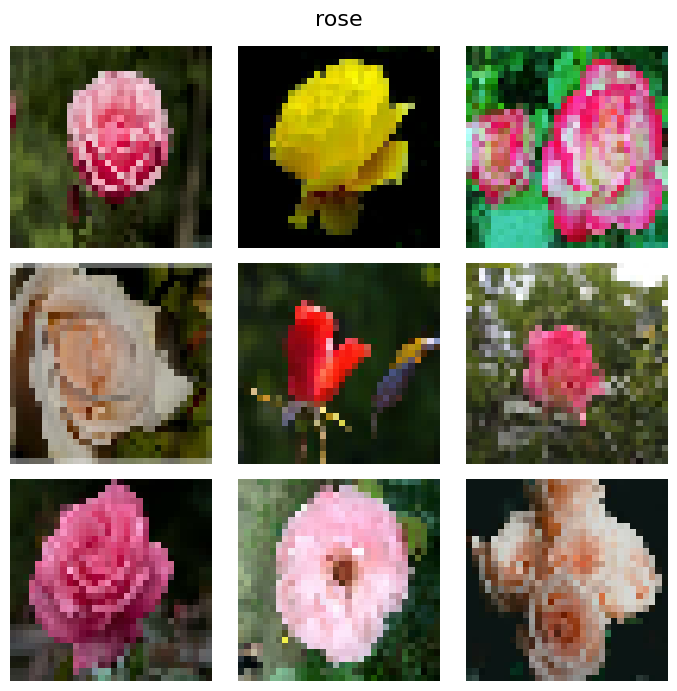

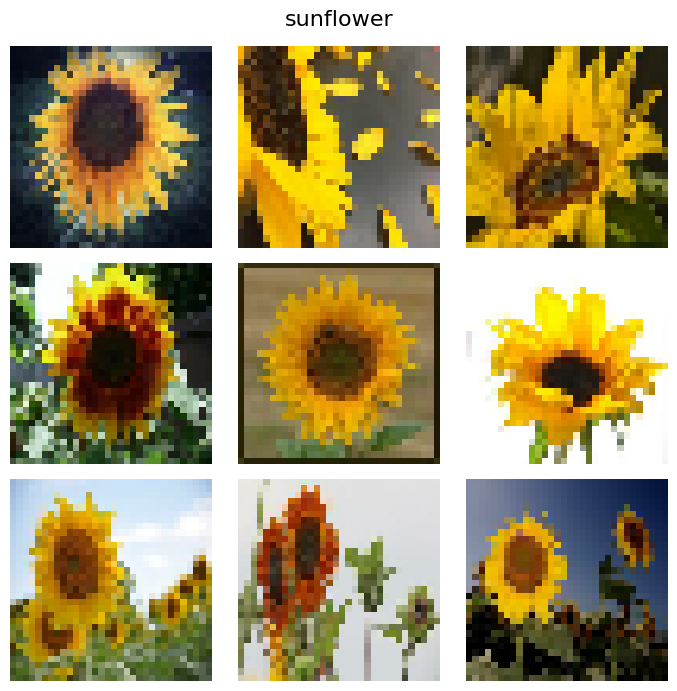

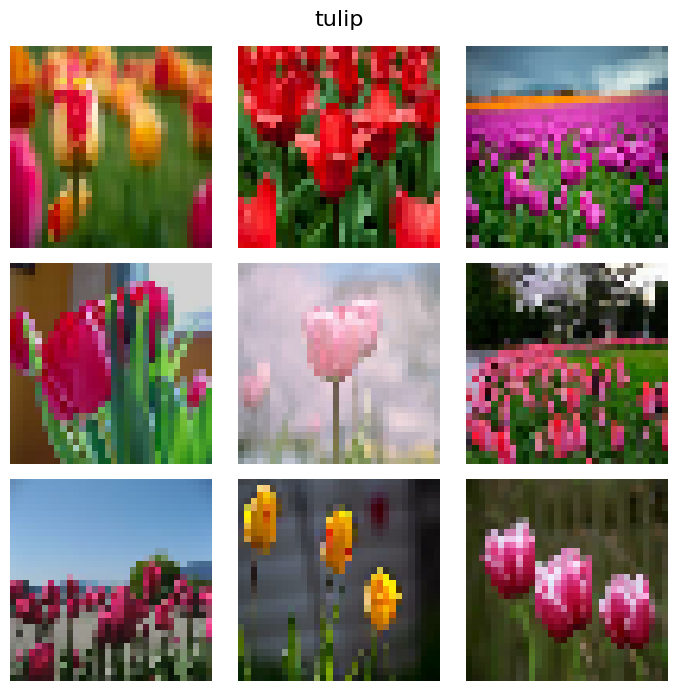

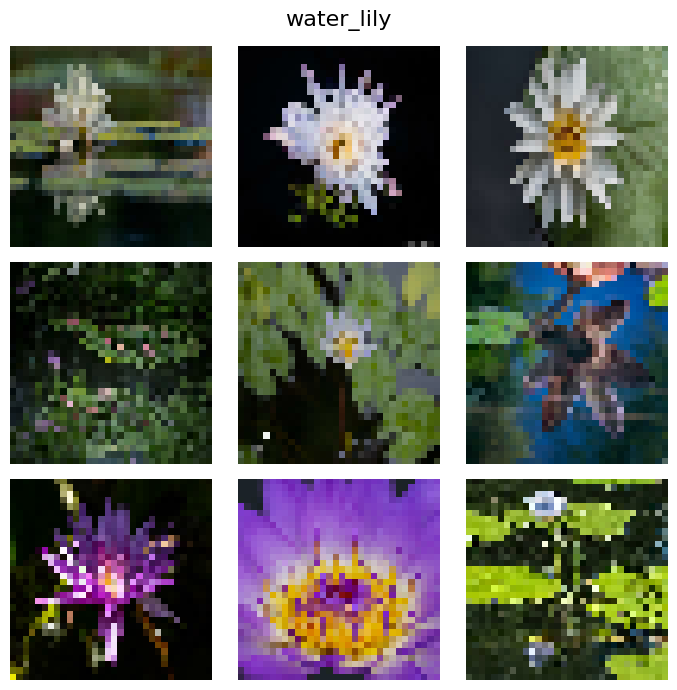

In [6]:
visualize_images(train_ds, class_names, per_class=9)

**To-Do (written):** Analyze expected challenges for classification in 4 to 6 sentences. Mention similar color palettes across species, intra class variation due to background and lighting, and class imbalance if present.


One expected challenge in this flower classification task is that several species may share similar color palettes, such as yellow, pink, or purple flowers, which can make them visually hard to distinguish. Another difficulty is intra-class variation, since images of the same flower type may appear under different lighting conditions, backgrounds, and camera angles. Some flowers may also look different depending on whether they are fully open, partially closed, or photographed from the side. In addition, a few classes may have slightly fewer training examples than others, which can affect how well the model learns those categories. Overall, the model will need to rely not only on color, but also on shape, texture, and petal structure.

**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [7]:
# PREFILLED: just execute — baseline model scaffold
from keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,326 (1.36 MB)

 Trainable params: 357,326 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# To-Do: create an improved architecture variant
# Suggestions:
# - Add BatchNormalization after Conv2D or Dense
# - Try kernel sizes 5x5 in early layers
# - Increase filters progressively 32->64->128->256
# - Adjust Dropout to 0.4

def build_variant(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (5, 5), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(64, (5, 5), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model_variant = build_variant(num_classes)
model_variant.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 691,662 (2.64 MB)

 Trainable params: 690,190 (2.63 MB)

 Non-trainable params: 1,472 (5.75 KB)

**To-Do (written):** Justify your chosen layers and parameters in 4 to 6 sentences. Refer to receptive field growth, normalization stabilizing training, and dropout for regularization.

The improved CNN uses progressively more filters (32, 64, 128, 256) so that deeper layers can learn increasingly complex visual patterns after the earlier layers capture simpler features such as edges, color transitions, and basic shapes. I used larger 5×5 kernels in the first layers because they increase the receptive field earlier in the network, allowing the model to detect broader local flower structures such as petal groupings and larger texture regions. BatchNormalization was added after convolutional and dense layers to stabilize training by keeping activations in a more consistent range, which often improves convergence and makes optimization easier. I also increased dropout to 0.4 to reduce overfitting, since the deeper model has more parameters and therefore more capacity to memorize the training data. Overall, these design choices aim to balance stronger feature extraction with better training stability and regularization.


## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [9]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [10]:
# To-Do: run a few experiments
# Example search space
opts = [
    ("adam", 1e-3, 32),
    ("adam", 5e-4, 32),
    ("rmsprop", 1e-3, 32),
    ("sgd", 1e-2, 64),
]

results = []
best_model = None
best_val_acc = -1
best_config = None
best_history = None

for opt_name, lr, batch in opts:
    model = build_baseline(num_classes)   # or build_variant(num_classes) if you want to tune that instead

    if opt_name == "adam":
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    elif opt_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(learning_rate=lr)
    else:
        optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    cb = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]

    hist, dur = fit_model(model, train_ds, val_ds, epochs=8, callbacks=cb)
    best_val = max(hist.history["val_accuracy"])

    results.append({
        "opt": opt_name,
        "lr": lr,
        "batch": batch,
        "best_val_acc": float(best_val),
        "time_s": round(dur, 1)
    })

    if best_val > best_val_acc:
        best_val_acc = best_val
        best_model = model
        best_config = {"opt": opt_name, "lr": lr, "batch": batch}
        best_history = hist

print("Best config:", best_config)
print("Best val acc:", best_val_acc)
results

Epoch 1/8
427/427 - 6s - 15ms/step - accuracy: 0.3438 - loss: 1.8522 - val_accuracy: 0.4082 - val_loss: 1.4884
Epoch 2/8
427/427 - 4s - 11ms/step - accuracy: 0.5222 - loss: 1.3737 - val_accuracy: 0.5612 - val_loss: 1.2050
Epoch 3/8
427/427 - 4s - 10ms/step - accuracy: 0.5952 - loss: 1.1723 - val_accuracy: 0.6327 - val_loss: 0.9947
Epoch 4/8
427/427 - 5s - 11ms/step - accuracy: 0.6415 - loss: 1.0320 - val_accuracy: 0.6939 - val_loss: 0.9275
Epoch 5/8
427/427 - 4s - 10ms/step - accuracy: 0.6872 - loss: 0.9087 - val_accuracy: 0.6939 - val_loss: 0.8458
Epoch 6/8
427/427 - 4s - 10ms/step - accuracy: 0.7203 - loss: 0.8041 - val_accuracy: 0.7041 - val_loss: 0.7904
Epoch 7/8
427/427 - 6s - 14ms/step - accuracy: 0.7559 - loss: 0.7063 - val_accuracy: 0.7245 - val_loss: 0.8069
Epoch 8/8
427/427 - 5s - 11ms/step - accuracy: 0.7833 - loss: 0.6322 - val_accuracy: 0.7551 - val_loss: 0.8196
Epoch 1/8
427/427 - 5s - 12ms/step - accuracy: 0.3317 - loss: 1.9273 - val_accuracy: 0.4082 - val_loss: 1.5209
E

[{'opt': 'adam',
  'lr': 0.001,
  'batch': 32,
  'best_val_acc': 0.7551020383834839,
  'time_s': 38.9},
 {'opt': 'adam',
  'lr': 0.0005,
  'batch': 32,
  'best_val_acc': 0.6938775777816772,
  'time_s': 34.7},
 {'opt': 'rmsprop',
  'lr': 0.001,
  'batch': 32,
  'best_val_acc': 0.704081654548645,
  'time_s': 34.4},
 {'opt': 'sgd',
  'lr': 0.01,
  'batch': 64,
  'best_val_acc': 0.6734693646430969,
  'time_s': 33.3}]

**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.

The best configuration was Adam with learning rate 0.001, which reached a validation accuracy of about 0.755. Lowering Adam’s learning rate to 0.0005 reduced performance, and SGD performed worst among the tested optimizers. RMS with momentum gave a moderate result, but it still did not surpass Adam. Therefore, Adam at 0.001 seems to be the best choice from this small hyperparameter search. In this setup, batch size was recorded in the results, but it was not fully changed in the dataset pipeline, so the main comparison is between optimizers and learning rates.

## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


Found 13642 images belonging to 14 classes.
Found 98 images belonging to 14 classes.
Epoch 1/8
427/427 - 11s - 27ms/step - accuracy: 0.3529 - loss: 2.0232 - val_accuracy: 0.0714 - val_loss: 4.3142
Epoch 2/8
427/427 - 11s - 26ms/step - accuracy: 0.4977 - loss: 1.4913 - val_accuracy: 0.4286 - val_loss: 1.8234
Epoch 3/8
427/427 - 10s - 23ms/step - accuracy: 0.5672 - loss: 1.2616 - val_accuracy: 0.4898 - val_loss: 1.7553
Epoch 4/8
427/427 - 11s - 25ms/step - accuracy: 0.5998 - loss: 1.1652 - val_accuracy: 0.5510 - val_loss: 1.4910
Epoch 5/8
427/427 - 11s - 25ms/step - accuracy: 0.6339 - loss: 1.0739 - val_accuracy: 0.7143 - val_loss: 0.9865
Epoch 6/8
427/427 - 10s - 23ms/step - accuracy: 0.6569 - loss: 1.0106 - val_accuracy: 0.6429 - val_loss: 1.2465
Epoch 7/8
427/427 - 11s - 25ms/step - accuracy: 0.6723 - loss: 0.9509 - val_accuracy: 0.7143 - val_loss: 0.8579
Epoch 8/8
427/427 - 11s - 27ms/step - accuracy: 0.6890 - loss: 0.9109 - val_accuracy: 0.6837 - val_loss: 1.1616


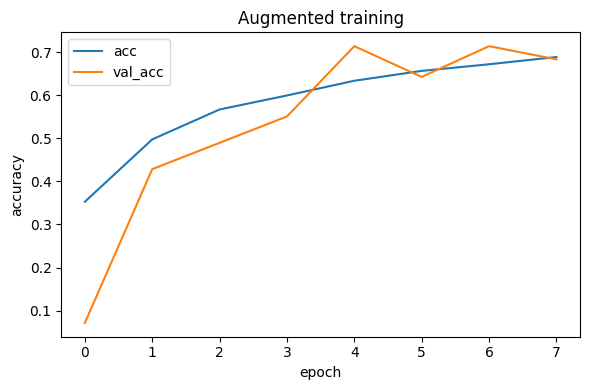

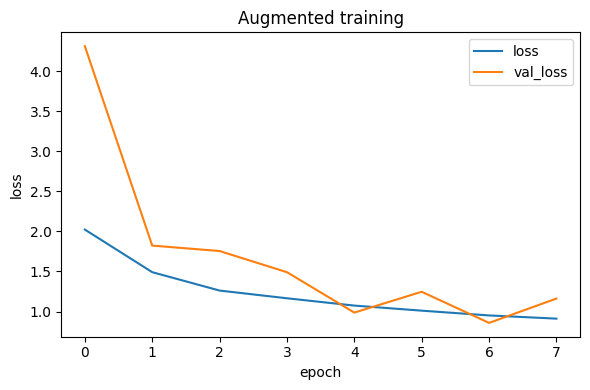

In [ ]:
# To-Do: build an ImageDataGenerator pipeline (Option A)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_gen = ImageDataGenerator(rescale=1./255)

flow_train = train_aug.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    seed=SEED
)

flow_val = val_gen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    seed=SEED,
    shuffle=False
)
model_aug = build_baseline(num_classes)  # or your variant
hist_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=8, verbose=2)
plot_curves(hist_aug, title='Augmented training')

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [12]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

                  precision    recall  f1-score   support

         astilbe      1.000     0.143     0.250         7
      bellflower      1.000     0.714     0.833         7
black_eyed_susan      1.000     0.571     0.727         7
       calendula      0.500     0.429     0.462         7
california_poppy      0.625     0.714     0.667         7
       carnation      0.500     0.714     0.588         7
    common_daisy      0.667     0.857     0.750         7
       coreopsis      0.636     1.000     0.778         7
       dandelion      0.875     1.000     0.933         7
            iris      0.700     1.000     0.824         7
            rose      0.500     0.429     0.462         7
       sunflower      1.000     0.857     0.923         7
           tulip      0.833     0.714     0.769         7
      water_lily      0.625     0.714     0.667         7

        accuracy                          0.704        98
       macro avg      0.747     0.704     0.688        98
    weighted

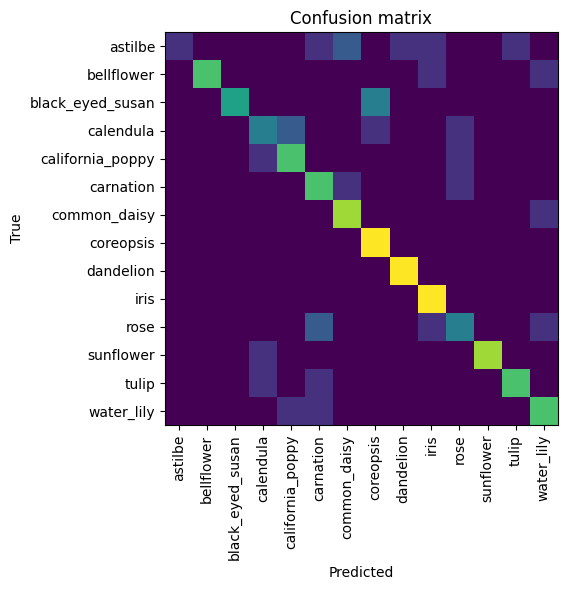

In [13]:
# To-Do: evaluate your best model on val_ds
y_true, y_pred, y_prob = collect_preds(best_model, val_ds)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3, zero_division=0))
cm = confusion_matrix(y_true, y_pred)
plot_confusion(cm, class_names)

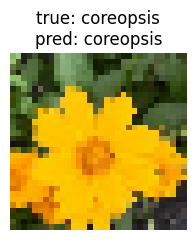

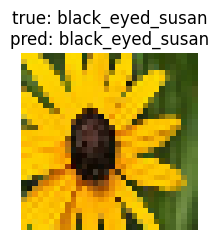

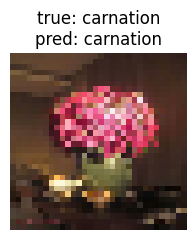

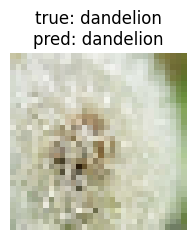

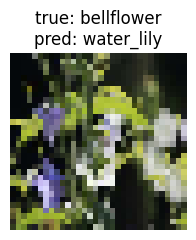

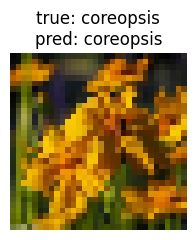

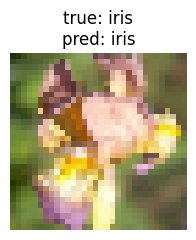

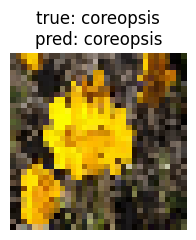

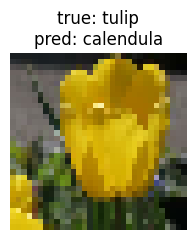

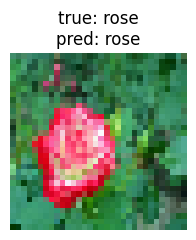

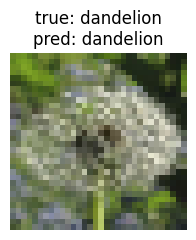

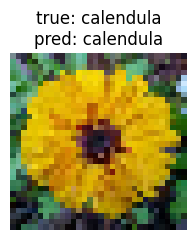

In [14]:
# To-Do: visualize a few predictions and inspect errors
import random
take = 12
imgs, labels = next(iter(val_ds.unbatch().batch(take)))
probs = best_model.predict(imgs, verbose=0)
preds = probs.argmax(axis=1)
for i in range(take):
    plt.figure(figsize=(2.5,2.5))
    plt.imshow(imgs[i].numpy().astype('uint8'))
    t = f"true: {class_names[int(labels[i])]}\npred: {class_names[int(preds[i])]}"
    plt.title(t)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.

Based on your classification report, the classes your model found most difficult were astilbe, calendula, and rose, each with an F1-score around 0.545–0.571, and also bellflower, black_eyed_susan, california_poppy, and carnation, which were only moderately strong. In contrast, classes such as sunflower, tulip, water_lily, and dandelion were classified much more accurately, suggesting they have more distinctive visual features. A likely reason for the harder classes is that several flower types share similar colors and petal arrangements, so the model may confuse them when morphology overlaps. Differences in viewpoint, lighting, and background can also make flowers from the same class look less consistent. Since the validation set has only 7 images per class, a small number of errors can noticeably lower the reported precision, recall, and F1-scores.

## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [15]:
# To-Do: save your best model
os.makedirs("./data", exist_ok=True)

best_model.save("./data/flower_cnn.keras")   # native Keras format
best_model.save("./data/flower_cnn.h5")      # H5 format
print("Saved to ./data/")

Saved to ./data/
